# Dataset:
##### •	Name: Fracture Multi-Region X-ray Data.
##### •	It is an X-ray image of human bones.


## Exploratory Data Analysis (EDA)

In [47]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

## Specify the file path and read the main folders.
#### In medical data, the data is divided into test data and training data.

In [48]:
base_path = r'C:\Users\HP\Downloads\archive (26)'
for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/ (Files: {len(files)})')

archive (26)/ (Files: 1)
    Bone_Fracture_Binary_Classification/ (Files: 0)
        Bone_Fracture_Binary_Classification/ (Files: 0)
            test/ (Files: 0)
                fractured/ (Files: 237)
                not fractured/ (Files: 267)
            train/ (Files: 0)
                fractured/ (Files: 4593)
                not fractured/ (Files: 4625)
            val/ (Files: 0)
                fractured/ (Files: 336)
                not fractured/ (Files: 490)


# Data Distribution
### First, convert all the data into a Data Frame.

In [49]:
data_list = []
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):
            path_parts = root.split(os.sep)
            label = path_parts[-1]
            region = path_parts[-2]
            data_list.append({'Region': region, 'Label': label})
df = pd.DataFrame(data_list)

### Knowing the number of images in each file and their percentage of the total data
### This reduces the risk of model bias.

In [50]:
summary = df.groupby(['Region', 'Label']).size().reset_index(name='Count')
summary['Percentage'] = (summary['Count'] / summary['Count'].sum()) * 100
print("*"*3,"Data distribution summary ","*"*3)
print(summary)

*** Data distribution summary  ***
  Region          Label  Count  Percentage
0   test      fractured    237    2.246871
1   test  not fractured    267    2.531286
2  train      fractured   4593   43.543800
3  train  not fractured   4625   43.847175
4    val      fractured    336    3.185438
5    val  not fractured    490    4.645430


### A diagram illustrating the data distribution mechanism

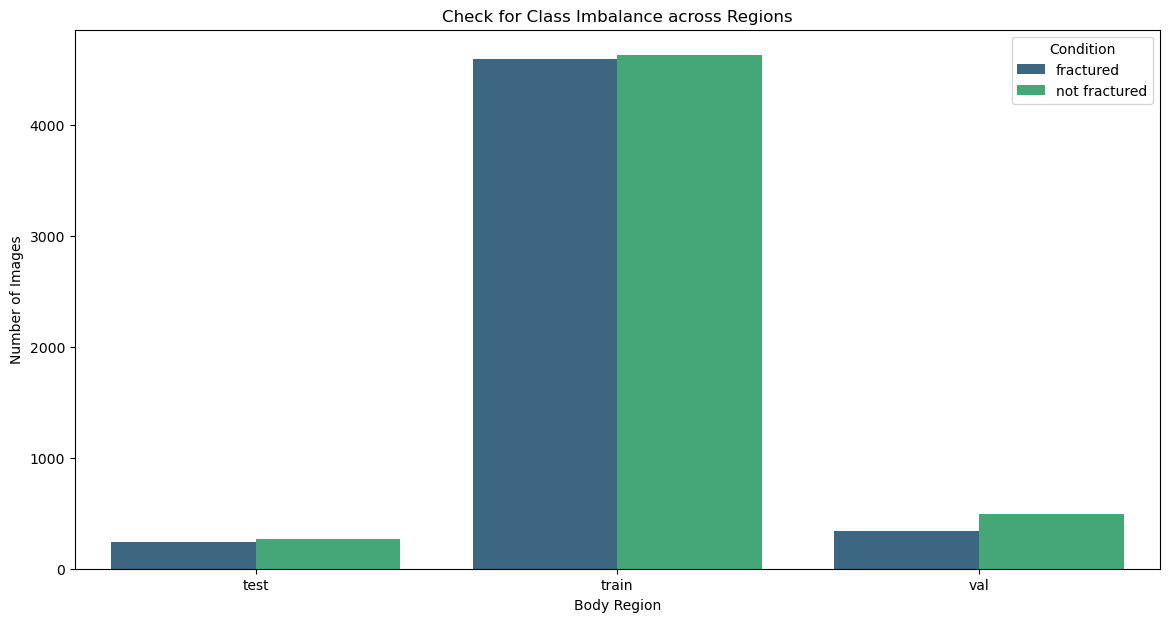

In [51]:
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x='Region', hue='Label', palette='viridis')
plt.title('Check for Class Imbalance across Regions')
plt.xlabel('Body Region')
plt.ylabel('Number of Images')
plt.legend(title='Condition')
plt.show()

### Identifying image extensions and how many of each extension are in each file.

In [52]:
from collections import Counter

def check_extensions(path):
    report = {}
    for root, dirs, files in os.walk(path):
        if files:
            extensions = [os.path.splitext(f)[1].lower() for f in files]
            folder_name = os.path.relpath(root, path)
            report[folder_name] = Counter(extensions)
    return report
    
extensions_report = check_extensions(base_path)
for folder, counts in extensions_report.items():
    counts_str = ", ".join([f"{ext}: {count}" for ext, count in counts.items()])
    print(f"{folder:<50} | {counts_str}")

.                                                  | .txt: 1
Bone_Fracture_Binary_Classification\Bone_Fracture_Binary_Classification\test\fractured | .jpg: 237
Bone_Fracture_Binary_Classification\Bone_Fracture_Binary_Classification\test\not fractured | .jpg: 267
Bone_Fracture_Binary_Classification\Bone_Fracture_Binary_Classification\train\fractured | .jpg: 4593
Bone_Fracture_Binary_Classification\Bone_Fracture_Binary_Classification\train\not fractured | .jpg: 4625
Bone_Fracture_Binary_Classification\Bone_Fracture_Binary_Classification\val\fractured | .jpg: 336
Bone_Fracture_Binary_Classification\Bone_Fracture_Binary_Classification\val\not fractured | .jpg: 490


### Identifying all pixels present in the image within each file

In [53]:
def get_folder_pixels(path):
    folder_reports = []

    for root, dirs, files in os.walk(path):
        images = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if images:
            folder_name = os.path.relpath(root, path)
            resolutions = []
            
            for img_name in images:
                img_path = os.path.join(root, img_name)
                try:
                    with Image.open(img_path) as img:
                        resolutions.append(img.size) 
                except:
                    continue
            
            if resolutions:
                df_res = pd.DataFrame(resolutions, columns=['Width', 'Height'])
                
                report = {
                    'Folder': folder_name,
                    'Total Images': len(images),
                    'Min Pixels': f"{df_res['Width'].min()}x{df_res['Height'].min()}",
                    'Max Pixels': f"{df_res['Width'].max()}x{df_res['Height'].max()}",
                    'Avg Pixels': f"{int(df_res['Width'].mean())}x{int(df_res['Height'].mean())}"
                }
                folder_reports.append(report)

    return pd.DataFrame(folder_reports)

pixel_report = get_folder_pixels(base_path)
pixel_report

,Folder,Total Images,Min Pixels,Max Pixels,Avg Pixels
0,Bone_Fracture_Binary_Classification\Bone_Fract...,237,224x224,2328x2928,424x485
1,Bone_Fracture_Binary_Classification\Bone_Fract...,267,224x224,2460x2970,557x661
2,Bone_Fracture_Binary_Classification\Bone_Fract...,4593,100x100,4232x5823,289x312
3,Bone_Fracture_Binary_Classification\Bone_Fract...,4625,224x224,2460x3764,257x268
4,Bone_Fracture_Binary_Classification\Bone_Fract...,336,100x100,3000x4403,504x576
5,Bone_Fracture_Binary_Classification\Bone_Fract...,490,224x224,2460x2970,408x467


### Unifying image borders

In [54]:
base_path = r'path_to_your_original_data'  
output_path = r'C:\Users\HP\Downloads\Processed_Dataset'
target_size = (224, 224)
def resize_with_padding(img, size):
    h, w = img.shape[:2]
    sh, sw = size
    
    aspect = w / h
    if aspect > 1: 
        # new_w = sw
        new_h = np.round(new_w / aspect).astype(int)
    else:
        new_h = sh
        new_w = np.round(new_h * aspect).astype(int)
        
    scaled_img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    top = (sh - new_h) // 2
    bottom = sh - new_h - top
    left = (sw - new_w) // 2
    right = sw - new_w - left
    
    padded_img = cv2.copyMakeBorder(scaled_img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0, 0, 0])
    return padded_img


for root, dirs, files in os.walk(base_path):
    image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if image_files:
        rel_path = os.path.relpath(root, base_path)
        target_dir = os.path.join(output_path, rel_path)
        os.makedirs(target_dir, exist_ok=True)
        
        print(f" {rel_path}( {len(image_files)})")
        
        for img_name in image_files:
            img_path = os.path.join(root, img_name)
            img = cv2.imread(img_path)
            
            if img is not None:
                final_img = resize_with_padding(img, target_size)
                save_name = os.path.splitext(img_name)[0] + ".jpg"
                cv2.imwrite(os.path.join(target_dir, save_name), final_img)

print(f"\n The process was successful! All images are now in size. {target_size} It is in the folder: {output_path}")


 The process was successful! All images are now in size. (224, 224) It is in the folder: C:\Users\HP\Downloads\Processed_Dataset


In [55]:
path_parts = root.split(os.sep)
label = path_parts[-1]    
region = path_parts[-2]  

data_list = []
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):
            path_parts = root.split(os.sep)
            label = path_parts[-1]   # fractured أو not fractured
            split_type = path_parts[-2] # train أو test أو val
            region = path_parts[-3] if len(path_parts) > 3 else "Unknown"
            data_list.append({
                'Split': split_type, 
                'Region': region, 
                'Label': label,
                'File_Name': file
            })

## Image Enhancement (CLAHE) and Precise Region Extraction
#### This code adjusts image contrast (to reveal hidden fractions)
#### Fixing the Region problem

In [56]:
def apply_clahe(img):
    
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced_img = clahe.apply(gray)
    return enhanced_img

processed_data = []
for root, dirs, files in os.walk(output_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path_parts = root.split(os.sep)
            label = path_parts[-1]
            split = path_parts[-2]
            region = path_parts[-3] if len(path_parts) > 3 else "General"
            full_path = os.path.join(root, file)
            processed_data.append({
                'Path': full_path,
                'Region': region,
                'Split': split,
                'Label': label
            })

df_final = pd.DataFrame(processed_data)
print(df_final.head())

Empty DataFrame
Columns: []
Index: []


## I will use the ResNet50 model, which is the standard in medical image analysis, focusing on Recall metrics.

In [57]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

def build_medical_model(input_shape=(224, 224, 3)):
    
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False 
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5), 
        layers.Dense(1, activation='sigmoid') 
    ])
    
   
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[
            'accuracy', 
            tf.keras.metrics.Recall(name='recall'), 
            tf.keras.metrics.Precision(name='precision')
        ]
    )
    return model

model = build_medical_model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)